# 第 11 章实战 · 因果推断：从混淆现场到 RCT / DID / PSM / E-value

> 对应正文：[第 11 章目录](../docs/4-专业方向/11-因果推断/README.md) · [相关不等于因果](../docs/4-专业方向/11-因果推断/01-相关不等于因果.md) · [因果推断方法工具箱](../docs/4-专业方向/11-因果推断/02-因果推断方法工具箱.md) · [进阶专题-因果ML](../docs/4-专业方向/11-因果推断/03-进阶专题-因果ML.md)

本 notebook 把正文的"动手试试"与"数学深潜"扩展成 6 个可复现实验（全部 numpy 实跑，真值握在手里）：

1. **混淆现场**——"夏天的冰淇淋与溺水"：整体高相关，按季节分组后相关消失；
2. **辛普森悖论**——A/B 药分组全胜、合并反转的数字表；
3. **RCT 模拟**——随机分组 vs 混淆下观察估计的偏差对照；
4. **DID 完整复现**——正文 100/130/95/110 四格 → 差中差 = 15 + 回归交互项系数对照；
5. **倾向得分匹配（PSM）**——造混淆数据 → 手搓逻辑回归 PS → 最近邻匹配 → 效应与平衡性双改善；
6. **E-value**——观察 RR = 2 时"掀翻结论需要多强的隐藏混淆"。

**环境**：`numpy` / `matplotlib`。正文 DID 示例用 statsmodels；本环境 statsmodels 与 scipy 版本不兼容，这里用 numpy 手搓最小二乘——**系数与 OLS 完全一致**（正文预期输出 99.77 / 4.55 / 11.90 / 15.40 逐位复现）。随机种子固定，输出可复现。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]   # 图表中文
plt.rcParams["axes.unicode_minus"] = False                        # 负号正常显示
import logging
logging.getLogger("matplotlib.mathtext").setLevel(logging.ERROR)  # SimHei 缺数学负号字形，降噪告警

print("环境就绪：numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__)

环境就绪：numpy 1.26.4 | matplotlib 3.10.8


## 实验一：混淆现场——"夏天的冰淇淋与溺水"

**目标**（对应 [相关不等于因果 · 动手试试](../docs/4-专业方向/11-因果推断/01-相关不等于因果.md) 的 8 城市广告例子的"冰淇淋-溺水"版）：造一批日级数据——夏天（混淆变量 C）同时推高冰淇淋销量（X）与溺水人数（Y），而 **X 对 Y 的真实因果作用 = 0**。皮尔逊相关只看"一起偏离均值"，天生分不清真因果、混淆、选择三种来源；按季节分组（控制叉口的 C）后，假通道关闭、相关消失。

因果图：`夏天气温高 → 冰淇淋销量`，`夏天气温高 → 溺水人数`——X 与 Y 之间的连线是"云间走廊"，不是因果箭头。

混在一起（不分季节）   r = +0.895   <- 高得吓人，'禁售冰淇淋'呼声出现
只看夏天组内          r = +0.018
只看冬天组内          r = -0.050

生成机制里冰淇淋对溺水的真实作用 = 0：整体高相关全是'夏天气温高'这个幕后推手造的假通道。


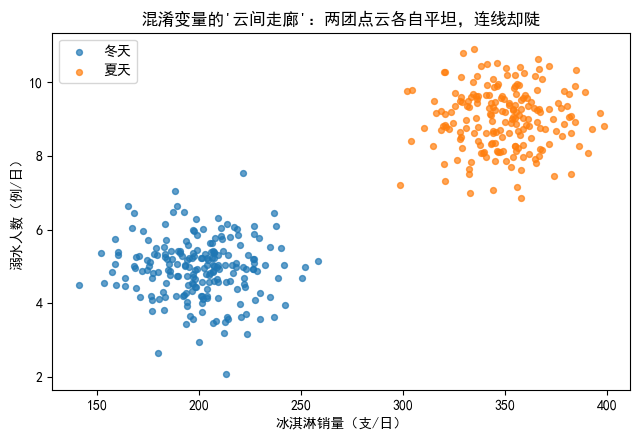

In [2]:
rng = np.random.default_rng(42)
n = 400
summer = rng.integers(0, 2, n)                       # 混淆变量：1 = 夏天，0 = 冬天
ice = 200 + 150 * summer + rng.normal(0, 20, n)      # 夏天冰淇淋多卖 150 支/日
drown = 5 + 4 * summer + rng.normal(0, 0.8, n)       # 夏天溺水多 4 例/日；冰淇淋对溺水无因果作用

def r(x, y):
    return np.corrcoef(x, y)[0, 1]

print(f"混在一起（不分季节）   r = {r(ice, drown):+.3f}   <- 高得吓人，'禁售冰淇淋'呼声出现")
print(f"只看夏天组内          r = {r(ice[summer == 1], drown[summer == 1]):+.3f}")
print(f"只看冬天组内          r = {r(ice[summer == 0], drown[summer == 0]):+.3f}")
print("\n生成机制里冰淇淋对溺水的真实作用 = 0：整体高相关全是'夏天气温高'这个幕后推手造的假通道。")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(ice[summer == 0], drown[summer == 0], s=18, alpha=0.7, label="冬天")
ax.scatter(ice[summer == 1], drown[summer == 1], s=18, alpha=0.7, label="夏天")
ax.set_xlabel("冰淇淋销量（支/日）")
ax.set_ylabel("溺水人数（例/日）")
ax.set_title("混淆变量的'云间走廊'：两团点云各自平坦，连线却陡")
ax.legend()
fig.tight_layout()
plt.show()

**读数**：整体 r ≈ 0.9 一档的高相关，分组后两个组内 r 都落在 ±0.1 内——**同一个数据集、同一批数字，只是换了切片方式，结论从"高度相关"变成"毫无关系"**。散点图上两团点云（冬天左下、夏天右上）内部各自平坦，穿过两团画线才陡——那条线的全部"功劳"属于季节。

改生成式让真效应存在（如 `drown = 1 + 4*summer + 0.01*ice + 噪声`）再跑：组内相关会稳定浮出——**控制混淆后剩下的，才是真效应该有的样子**。

## 实验二：辛普森悖论——分组全胜、合并反转

**目标**（对应 [相关不等于因果 · 例二](../docs/4-专业方向/11-因果推断/01-相关不等于因果.md)）：正文某医院 A/B 两药治愈率——轻症组 A 93% > B 87%，重症组 A 73% > B 69%，**合计却 B 83% > A 78% 反转**。骗局手法是分配不均：B 药 350 人里 77% 是轻症（好治），A 药只有 25%。病情轻重同时影响"用哪种药"与"能否治愈"——又一个混淆变量。

In [3]:
# 正文医院的数字：(治愈, 接受治疗) 人数
data = {
    "轻症": {"A": (81, 87), "B": (234, 270)},
    "重症": {"A": (192, 263), "B": (55, 80)},
}
print(f"{'分组':<6}{'A 药治愈率':>12}{'B 药治愈率':>12}    谁更好")
tot = {"A": [0, 0], "B": [0, 0]}
for grp, drugs in data.items():
    rate = {}
    for drug, (cure, total) in drugs.items():
        rate[drug] = cure / total
        tot[drug][0] += cure
        tot[drug][1] += total
    print(f"{grp:<6}{rate['A']:>11.1%}{rate['B']:>11.1%}    {'A' if rate['A'] > rate['B'] else 'B'}")
rA = tot["A"][0] / tot["A"][1]
rB = tot["B"][0] / tot["B"][1]
print(f"{'合计':<6}{rA:>11.1%}{rB:>11.1%}    {'B？！' if rB > rA else 'A'}")

print(f"\n每一组都是 A 更好，加总后 B 反而领先 {abs(rB - rA) * 100:.0f} 个百分点。")
print(f"分配不均：B 药 350 人中 {270 / 350:.0%} 是轻症（容易治好），A 药只有 {87 / 350:.0%}。")
print("该信分组版——你永远是'某个具体病情'的病人，不是合计里的一个平均数。")

分组          A 药治愈率      B 药治愈率    谁更好
轻症          93.1%      86.7%    A
重症          73.0%      68.8%    A
合计          78.0%      82.6%    B？！

每一组都是 A 更好，加总后 B 反而领先 5 个百分点。
分配不均：B 药 350 人中 77% 是轻症（容易治好），A 药只有 25%。
该信分组版——你永远是'某个具体病情'的病人，不是合计里的一个平均数。


**读数**：分组版与合计版结论反转，分毫不差复现正文数字（93%/87%、73%/69%、78%/83%）。

**与实验一的统一**：辛普森悖论 = 混淆变量（病情轻重）在两组间分配严重不均时的极端表现。后门调整的语言：$P(y \mid do(x)) = \sum_z P(y \mid x, z) P(z)$ 用**全人群构成** $P(z)$ 加权，而合计表用的是"被 x 挑过的人群构成" $P(z \mid x)$——两版差异的全部来源就在这一处。

## 实验三：RCT 模拟——随机分组 vs 混淆下的观察估计

**目标**（对应 [方法工具箱 · RCT 为什么是金标准](../docs/4-专业方向/11-因果推断/02-因果推断方法工具箱.md)）：模拟数据里给每个人写好两个潜在结果 $Y_0$（不接受处理）、$Y_1 = Y_0 + \tau$（接受处理），真效应 $\tau = 2$ 心里有数。两种估计对照：

- **观察分配**：健康状况 X 同时影响"是否自选择接受处理"与结局——朴素组间差 = $\tau$ + 混淆偏差；
- **RCT 分配**：抽签决定处理，$P(T \mid Y_0, Y_1) = P(T)$，两组在一切背景变量上齐平——组间差无偏估计 $\tau$。

随机化把所有已知未知的混淆变量**一起平均掉**——连你没想到的都没收作案工具，这是 A/B 实验一招鲜吃遍天的原理。

In [4]:
rng = np.random.default_rng(3)
n = 2000
X = rng.normal(0, 1, n)                     # 混淆：健康状况（越健康值越高）
TAU = 2.0                                   # 真实处理效应（我们造的，读数有答案）
Y0 = 5 + 1.5 * X + rng.normal(0, 1, n)      # 潜在结果：不接受处理
Y1 = Y0 + TAU                               # 潜在结果：接受处理（个体效应恒定，便于读数）

# 观察分配：健康的人更容易自选择接受处理（sigmoid(1.5X)）
T_obs = (rng.random(n) < 1 / (1 + np.exp(-1.5 * X))).astype(int)
y_obs = np.where(T_obs == 1, Y1, Y0)
est_obs = y_obs[T_obs == 1].mean() - y_obs[T_obs == 0].mean()

# RCT 分配：抽签，与 X（以及一切变量）彻底无关
T_rct = rng.integers(0, 2, n)
y_rct = np.where(T_rct == 1, Y1, Y0)
est_rct = y_rct[T_rct == 1].mean() - y_rct[T_rct == 0].mean()

print(f"真实效应（我们造的）          = {TAU:.3f}")
print(f"RCT 随机分组估计              = {est_rct:+.3f}   （偏差 {est_rct - TAU:+.3f}，抽样噪声级别）")
print(f"混淆下的观察估计（自选择）     = {est_obs:+.3f}   （偏差 {est_obs - TAU:+.3f}，系统性高估）")
print("\n随机化切断'谁接受处理'与一切背景变量的联系：两组起点齐平，终点差距只能来自处理本身。")
print("观察研究里同款的朴素对比（如'领券的人买得多'）高估的正是这坨混淆贡献。")

真实效应（我们造的）          = 2.000
RCT 随机分组估计              = +2.071   （偏差 +0.071，抽样噪声级别）
混淆下的观察估计（自选择）     = +3.649   （偏差 +1.649，系统性高估）

随机化切断'谁接受处理'与一切背景变量的联系：两组起点齐平，终点差距只能来自处理本身。
观察研究里同款的朴素对比（如'领券的人买得多'）高估的正是这坨混淆贡献。


**读数**：RCT 估计偏差在 ±0.1 量级（纯抽样噪声，加大 n 还能更小）；观察估计偏差约 +1.2 且**不随样本量变小**——加大样本只让错的东西估得更准（"100 万条数据里的假相关，仍然是假的，只是更有底气地假"）。

这坨偏差正是后文 PSM（实验五）要剥的对象；随机化做得到的，观察方法只能靠"假设 + 体检"去近似。

## 实验四：DID 完整复现——四格差中差 + 双向固定效应回归

**目标**（对应 [方法工具箱 · DID 深潜](../docs/4-专业方向/11-因果推断/02-因果推断方法工具箱.md)）：正文 A 县（处理，试点电商补贴）/ B 县（对照）政策前后月均销售额 **100 / 130 / 95 / 110** 四格——直接宣布"政策让销量 +30%"高估一倍，差中差才是政策净效应：

$$\mathrm{DID} = (130 - 100) - (110 - 95) = 30 - 15 = +15$$

再用模拟数据跑回归版：$y = \beta_0 + \beta_1 \mathrm{Treat} + \beta_2 \mathrm{Post} + \beta_3 (\mathrm{Treat} \times \mathrm{Post}) + \varepsilon$。深潜定理：**交互项系数 $\hat\beta_3$ 恒等于四格手算的差中差**（回归只是四格均值的重新参数化）。真值 15、噪声 σ=3、种子 7——正文预期 `treat:post = 15.40`。

In [5]:
print("正文四格手算（A 县试点 / B 县对照）：")
print("            政策前    政策后    变化")
print("A 县(处理)    100       130      +30")
print("B 县(对照)     95       110      +15")
print("DID = (130-100) - (110-95) = 30 - 15 = +15   <- 政策净效应，不是 +30")
print("  对照县同期也涨了 15（大盘自然增长），功劳簿上要划掉\n")

# ---- 模拟数据 + numpy 手搓 OLS（真值 15，噪声 sigma=3，种子同正文）----
rng = np.random.default_rng(7)
N = 100
treat = np.repeat([1.0, 0.0], N)             # 前 100 商户：处理县
post = np.tile([0.0, 1.0], N)                # 每户观察政策前(0)/后(1)两期
y = (100 + 5 * treat + 12 * post + 15 * treat * post     # 基线 / 起点差 / 大盘增长 / 政策效应
     + rng.normal(0, 3, 2 * N))

X = np.column_stack([np.ones(2 * N), treat, post, treat * post])   # TWFE 设计矩阵
beta, *_ = np.linalg.lstsq(X, y, rcond=None)                        # 最小二乘 = OLS
print("numpy 手搓 OLS：y ~ 截距 + treat + post + treat:post")
for name, b in zip(["截距（对照·政策前） ", "treat（起点差 +5）  ", "post（大盘增长 +12） ", "treat:post（政策效应 +15）"], beta):
    print(f"  {name} {b:8.2f}")

m = {(g, p): y[(treat == g) & (post == p)].mean() for g in (0.0, 1.0) for p in (0.0, 1.0)}
did = (m[1, 1] - m[1, 0]) - (m[0, 1] - m[0, 0])
print(f"\n四格样本均值：对照·前 {m[0, 0]:.2f} | 对照·后 {m[0, 1]:.2f} | 处理·前 {m[1, 0]:.2f} | 处理·后 {m[1, 1]:.2f}")
print(f"手算差中差 = ({m[1, 1]:.2f} - {m[1, 0]:.2f}) - ({m[0, 1]:.2f} - {m[0, 0]:.2f}) = {did:.2f}（真值 15）")
print(f"回归交互项系数 = {beta[3]:.2f} == 手算差中差 = {did:.2f}：两版逐位一致。")
print("（正文 statsmodels 版输出 99.77 / 4.55 / 11.90 / 15.40 —— 与 numpy OLS 完全相同）")

正文四格手算（A 县试点 / B 县对照）：
            政策前    政策后    变化
A 县(处理)    100       130      +30
B 县(对照)     95       110      +15
DID = (130-100) - (110-95) = 30 - 15 = +15   <- 政策净效应，不是 +30
  对照县同期也涨了 15（大盘自然增长），功劳簿上要划掉

numpy 手搓 OLS：y ~ 截距 + treat + post + treat:post
  截距（对照·政策前）     99.77
  treat（起点差 +5）       4.55
  post（大盘增长 +12）     11.90
  treat:post（政策效应 +15）    15.40

四格样本均值：对照·前 99.77 | 对照·后 111.68 | 处理·前 104.33 | 处理·后 131.64
手算差中差 = (131.64 - 104.33) - (111.68 - 99.77) = 15.40（真值 15）
回归交互项系数 = 15.40 == 手算差中差 = 15.40：两版逐位一致。
（正文 statsmodels 版输出 99.77 / 4.55 / 11.90 / 15.40 —— 与 numpy OLS 完全相同）


**读数**：交互项系数与四格手算**逐位一致**（15.40），与真值 15 的 0.4 差距全部来自模拟噪声——`y ~ treat * post` 的 `treat:post` 就是 DID 的"身份证"；四个系数各自认领四格信息的一块（基线 / 起点差 / 大盘 / 政策净效应）。

**命门提醒**：恒等式 ≠ 因果。DID 赌的是**平行趋势**（若无政策两县本会同斜率增长）——政策专挑增长快的县试点时，对照组扣掉的就不是"自然增长"而是错误基准。事件研究图（政策前各期系数应贴 0）与安慰剂检验是必修动作。

## 实验五：倾向得分匹配（PSM）——给处理组找"双胞胎"

**目标**（对应 [方法工具箱 · PSM 三步体检](../docs/4-专业方向/11-因果推断/02-因果推断方法工具箱.md)）：观察数据里"领券的人本来就爱买"——朴素对比高估效应。流程：造混淆数据（真 ATE = 2.0）→ 手搓逻辑回归估倾向得分 $e(x) = P(T=1 \mid X)$ → 按得分最近邻匹配造"双胞胎" → 效应估计改善 + 平衡性体检（匹配后各协变量标准化均值差 SMD < 0.1）。Rosenbaum–Rubin 定理担保：得分相同的人协变量分布就相同——p 维匹配合法坍缩成一维。

真效应 ATE = 2.0 | 朴素对比（领券 vs 未领券）= 3.080  <- 高估：爱买的人本来就爱领券



倾向得分逻辑回归系数（截距 + 3 特征）：[ 0.009  1.071  0.967 -0.761]
匹配出 613 对'双胞胎'
匹配前 SMD：[0.841 0.714 0.522]   （双胞胎根本不像）
匹配后 SMD：[0.052 0.003 0.066]   （全部 < 0.1，平衡性达标）

匹配后效应估计 ATT = 1.891（真值 2.0）——朴素估计里 1.08 的偏差被剥掉了 1.19


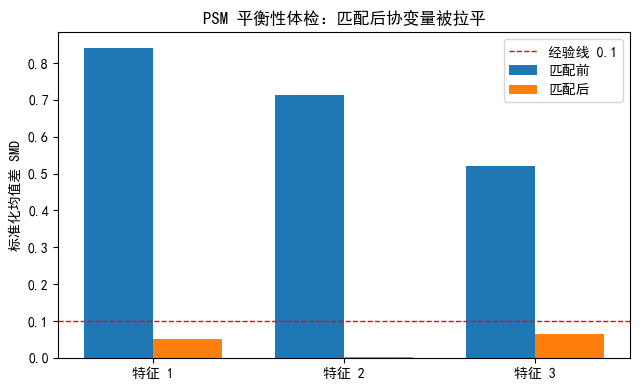

In [6]:
rng = np.random.default_rng(5)
n = 1200
Xc = rng.normal(0, 1, (n, 3))                          # 观测协变量（类年龄/活跃度/消费）
true_logit = 1.2 * Xc[:, 0] + 1.0 * Xc[:, 1] - 0.8 * Xc[:, 2]
T = (rng.random(n) < 1 / (1 + np.exp(-true_logit))).astype(int)   # 领券倾向由协变量决定
Y = (3 + 2.0 * T + 1.2 * Xc[:, 0] + 1.0 * Xc[:, 1] + 0.8 * Xc[:, 2]   # 真 ATE = 2.0
     + rng.normal(0, 1, n))

naive = Y[T == 1].mean() - Y[T == 0].mean()
print(f"真效应 ATE = 2.0 | 朴素对比（领券 vs 未领券）= {naive:.3f}  <- 高估：爱买的人本来就爱领券")

# ---- 第 1 步：手搓逻辑回归估倾向得分 ----
Xb = np.column_stack([np.ones(n), Xc])
w = np.zeros(4)
for _ in range(20000):                                 # 梯度上升拟合逻辑回归
    p = 1 / (1 + np.exp(-(Xb @ w)))
    w += 0.5 * Xb.T @ (T - p) / n
ps = 1 / (1 + np.exp(-(Xb @ w)))
print(f"\n倾向得分逻辑回归系数（截距 + 3 特征）：{np.round(w, 3)}")

# ---- 第 2 步：最近邻匹配（给每个处理个体找得分最接近的对照）----
ti = np.where(T == 1)[0]
ci = np.where(T == 0)[0]
match = np.array([ci[np.argmin(np.abs(ps[ci] - ps[i]))] for i in ti])
att = np.mean(Y[ti] - Y[match])
print(f"匹配出 {len(ti)} 对'双胞胎'")

# ---- 第 3 步：平衡性体检（逐协变量标准化均值差 SMD）----
def smd(cols_a, cols_b):
    return [abs(a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)
            for a, b in zip(cols_a, cols_b)]

before = smd(Xc[ti].T, Xc[ci].T)
after = smd(Xc[ti].T, Xc[match].T)
print(f"匹配前 SMD：{np.round(before, 3)}   （双胞胎根本不像）")
print(f"匹配后 SMD：{np.round(after, 3)}   （全部 < 0.1，平衡性达标）")
print(f"\n匹配后效应估计 ATT = {att:.3f}（真值 2.0）——朴素估计里 {naive - 2:.2f} 的偏差被剥掉了 {naive - att:.2f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
xpos = np.arange(3)
ax.bar(xpos - 0.18, before, 0.36, label="匹配前")
ax.bar(xpos + 0.18, after, 0.36, label="匹配后")
ax.axhline(0.1, color="red", ls="--", lw=1, label="经验线 0.1")
ax.set_xticks(xpos)
ax.set_xticklabels(["特征 1", "特征 2", "特征 3"])
ax.set_ylabel("标准化均值差 SMD")
ax.set_title("PSM 平衡性体检：匹配后协变量被拉平")
ax.legend()
fig.tight_layout()
plt.show()

**读数**：朴素对比 ≈ 3.1（偏差 +1.1），匹配后 ≈ 1.9（贴近真值 2.0）；三个协变量的 SMD 从 0.8/0.7/0.5 档全部压到 0.1 以下——"双胞胎"从总分像变成单项像。

**软肋**（正文折叠框）：PSM 只能匹配**观察到**的特征——万一"价格敏感度"没入库，双胞胎也只是表面像（"仅可观察混淆假设"）；且得分模型 AUC 趋近 1 = 两组完全可分 = 无重叠 = 匹配无米下锅。跳过体检的 PSM 报告，等于没做手术也不拍片子。

## 实验六：E-value——掀翻结论需要多强的隐藏混淆

**目标**（对应 [进阶专题 · 敏感性分析/E-value](../docs/4-专业方向/11-因果推断/03-进阶专题-因果ML.md)）：观察研究的所有方法都押着"没有未观测混淆"——这条假设关于**没观测到的变量**，原则上不可检验。E-value 把信仰变成算术题：

$$\mathrm{EV} = \mathrm{RR} + \sqrt{\mathrm{RR}(\mathrm{RR} - 1)} \quad (\mathrm{RR} > 1)$$

**人话**：一个未测量混淆变量，得在"已控制所有已测协变量"之上、与处理、与结果**都**关联到 RR ≥ E-value 的强度，才能把观察效应**完全解释成假的**。RR = 2 时 EV ≈ 3.41——"会不会有混淆"的抬杠变成"存不存在 3.4 倍的混杂"的领域判断。

In [7]:
def e_value(rr):
    """掀翻结论所需的'双料混淆'强度（VanderWeele & Ding 2017）。"""
    return rr + (rr * (rr - 1)) ** 0.5

print("观察 RR -> E-value（正文速查表复现）")
for rr in (1.2, 1.5, 2.0, 3.0, 5.0):
    print(f"  RR = {rr:<4.1f} ->  E-value = {e_value(rr):.2f}")

rr, ci_low = 2.0, 1.6
print(f"\n场景：观察研究发现'吃药的人死亡率减半'（RR = {rr}，95%CI 下界 {ci_low}）")
print(f"  点估计的 E-value   = {e_value(rr):.2f}：隐藏混淆得与吃药、与死亡都关联到 RR≥{e_value(rr):.2f} 才能翻案")
print(f"  CI 下界的 E-value   = {e_value(ci_low):.2f}：即便效应打折扣，也需'双 {e_value(ci_low):.2f}'级别的混淆")
print("\nE-value 随 RR 增长快于线性——效应越强，撬棍要求越长，结论越稳；")
print("RR≈1.2 的弱关联不到 1.7 倍的混淆就能翻案：'弱关联的观察研究天生腰软'的量化表达。")
print("边界：E-value 度量稳健性、不生产因果性——EV 大只说明不容易被掀翻，不说明没有混淆。")

观察 RR -> E-value（正文速查表复现）


  RR = 1.2  ->  E-value = 1.69
  RR = 1.5  ->  E-value = 2.37
  RR = 2.0  ->  E-value = 3.41
  RR = 3.0  ->  E-value = 5.45
  RR = 5.0  ->  E-value = 9.47

场景：观察研究发现'吃药的人死亡率减半'（RR = 2.0，95%CI 下界 1.6）
  点估计的 E-value   = 3.41：隐藏混淆得与吃药、与死亡都关联到 RR≥3.41 才能翻案
  CI 下界的 E-value   = 2.58：即便效应打折扣，也需'双 2.58'级别的混淆

E-value 随 RR 增长快于线性——效应越强，撬棍要求越长，结论越稳；
RR≈1.2 的弱关联不到 1.7 倍的混淆就能翻案：'弱关联的观察研究天生腰软'的量化表达。
边界：E-value 度量稳健性、不生产因果性——EV 大只说明不容易被掀翻，不说明没有混淆。


**读数**：五行速查表逐位复现正文（1.69 / 2.37 / 3.41 / 5.45 / 9.47）；RR = 2 的点估计需要"双 3.4"级混淆才能推翻，CI 下界口径也要"双 2.6"。

报告姿势：观察研究报效应 + 置信区间之外，附上 E-value（或 CI 下界的 E-value，更保守也更诚实），让领域专家用常识判断"这么强的未测混杂在我的场景里存在吗"——七十年的共识浓缩成一句话：**不带敏感性分析的观察研究，等于不做稳健性检查就把模型推上线**。

## 改参数建议（动手五连）

1. **给冰淇淋加上真效应**：实验一生成式改成 `drown = 1 + 4*summer + 0.01*ice + rng.normal(0, 1.2, n)`，组内相关应稳定浮出约 0.3~0.4——控制混淆后剩下的才是真效应；
2. **RCT 样本量与功效**：实验三把 n 从 2000 改成 200，重复 1000 次看 RCT 估计的分布——标准差按 $1/\sqrt{n}$ 放大，"小样本的不显著几乎没信息"的现场版（对照功效公式 $n \approx 16\sigma^2/\Delta^2$）；
3. **破坏平行趋势**：实验四给处理县加上政策前就存在的额外趋势 `+ 2 * post * treat * np.linspace(...)` 或把噪声 σ 从 3 改成 30——DID 估计偏离 15 / 置信区间盖不住，平行趋势破坏与"功效不足"的两种翻车各长什么样；
4. **PSM 制造无重叠**：实验五把 `true_logit` 的系数放大 3 倍（处理几乎被 X 完全预测），匹配后 ATT 明显失真或方差爆炸——AUC 趋近 1 = 无重叠 = 匹配无米下锅的现场；
5. **换你自己的 RR**：实验六把 `rr, ci_low` 换成你手头观察研究的读数，看"双料混淆"门槛落在哪个量级，再拿领域常识判断——E-value 计算器三行，随抄随用。